### Student Information
Name:黃裕傑

Student ID:114232501

GitHub ID:eng-jack


---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

Import and Check Enviroment


In [1]:

# envirronment setup
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.feature_extraction.text import CountVectorizer
import helpers.data_mining_helpers as dmh
import sys
%load_ext autoreload
%autoreload 2
print(sys.executable) # my path


c:\Users\jack\AppData\Local\Programs\Python\Python313\python.exe


Data Preparation:
    read csv file and show 0-9
    

In [2]:
Reddit = pd.read_csv('newdataset/Reddit-stock-sentiment.csv')

Reddit.head(10)

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0
5,comment,2025-04-12 2:19:03,mmo4k9g,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,PolarNimbus,https://www.reddit.com/r/wallstreetbets/commen...,16,NaN,NaN,"Hoping to ejaculate in wet warm puss tonight, ...",0.500000,0.250000,1.0,"['tonight', 'puss']",0.0
6,comment,2025-04-11 12:37:23,mmjx7vz,stocks,Is the market in complete denial right now?,stoniey84,https://www.reddit.com/r/stocks/comments/1jwo1...,5,NaN,NaN,Trump will respond to china increasing their t...,0.380000,-0.108333,-1.0,"['JPow', 'Jerome', 'i', 'reporting', 'Trump', ...",-1.0
7,comment,2025-04-11 17:28:50,mmlhxwc,wallstreetbets,Retardation is on the menu boys! WSB is so back,OSRSkarma,https://i.redd.it/0yq2ftren8ue1.jpeg,-3,NaN,NaN,Confirmed not a trap. Its been like this for p...,0.700000,0.050000,1.0,"['Confirmed', 'mouth', 'word', 'trap']",0.0
8,comment,2021-02-01 15:36:32,gllyi5z,stocks,"It's fucking awful seeing the ""Silver"" misinfo...",Blondbox,https://www.reddit.com/r/stocks/comments/la34b...,1,NaN,NaN,Am I the only one seeing the cup & handle brea...,0.491818,0.057045,1.0,"['cup', 'Day', 'handle', 'pivot', 'Green', 'tr...",1.0
9,comment,2021-12-31 16:29:49,hqp3kt4,stockstobuytoday,Any cheap stocks under $10?,Zumuru,https://www.reddit.com/r/stockstobuytoday/comm...,2,NaN,NaN,HLGN is $10. Hurry and catch it now before it ...,0.000000,0.000000,0.0,"['HLGN', 'Hurry', 'moon']",1.0


In [3]:
Reddit[::100]

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
100,comment,2025-04-11 15:01:48,mmknyf6,StockMarket,The Trump administration is begging Xi Jinping...,Darkstar197,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,Do we have a copy of trump’s kindergarten grad...,0.400000,-0.050000,-1.0,"['certificate', 'version', 'form', '’', 'trump...",-1.0
200,comment,2025-04-11 14:42:17,mmkk04x,StockMarket,Trump: We Are Doing Really Well On Our Tariff ...,coochellamai,https://i.redd.it/uajqu4kxl7ue1.png,1,NaN,NaN,I need people to understand this man is NOT st...,0.604242,-0.260227,-1.0,"['plan', 'goal', 'man', 'USD', 'US', 'economy'...",1.0
300,comment,2022-04-23 20:11:55,i5x0o24,stockstobuytoday,Technical Analysis Thread.,saasfin,https://www.reddit.com/r/stockstobuytoday/comm...,1,NaN,NaN,[/](/),0.000000,0.000000,0.0,"['/', ']']",0.0
400,comment,2025-04-11 14:30:36,mmkhog3,StockMarket,"Trump is surrounded by a bunch of idiots, he s...",gonzo0815,https://i.redd.it/c2mmpy3qf7ue1.png,1,NaN,NaN,Imo it's bullshit for another reason: why woul...,0.391667,0.016667,1.0,"['reason', 'anything', 'relation', 'point', 'g...",-1.0
500,comment,2025-04-11 14:27:20,mmkh0uf,StockMarket,The Trump administration is begging Xi Jinping...,Bloodsucker_,https://edition.cnn.com/2025/04/10/politics/tr...,-2,NaN,NaN,Everyone is talking about the Bond market. But...,0.500000,0.000000,0.0,"['year', 'bond', 'everyone', 'market', 'Bond',...",0.0
600,comment,2025-04-11 13:55:11,mmkaotn,wallstreetbets,Weekly Earnings Thread 4/14 - 4/18,grhotz,https://i.redd.it/b51iqmecn7ue1.jpeg,2,NaN,NaN,Bank week is so boring. PUTS on NFLX,1.000000,-1.000000,-1.0,"['week', 'Bank', 'NFLX', 'Bank week']",-1.0
700,comment,2025-04-12 1:09:59,mmntum6,wallstreetbets,Retail giant TARGET has now declined for 10 co...,CuttyAllgood,https://i.redd.it/7tl6puv9waue1.jpeg,36,NaN,NaN,Donno why you’re getting downvoted. You’re not...,0.900000,-0.500000,-1.0,"['Donno', 'IMO']",1.0
800,comment,2025-04-11 15:27:34,mmkt7j7,stocks,Is the market in complete denial right now?,Vlistorito,https://www.reddit.com/r/stocks/comments/1jwo1...,4,NaN,NaN,"It's a pretty unremarkable product, but you wo...",0.625000,0.333333,1.0,"['information', 'distributor', 'product', 'com...",0.0


In [4]:
print(Reddit.columns)
Reddit.info()

Index(['type', 'datetime', 'post_id', 'subreddit', 'title', 'author', 'url',
       'upvotes', 'downvotes', 'upvote_ratio', 'text', 'subjectivity',
       'polarity', 'sentiment', 'entities', 'label'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   type          847 non-null    object 
 1   datetime      847 non-null    object 
 2   post_id       847 non-null    object 
 3   subreddit     847 non-null    object 
 4   title         847 non-null    object 
 5   author        847 non-null    object 
 6   url           847 non-null    object 
 7   upvotes       847 non-null    int64  
 8   downvotes     64 non-null     float64
 9   upvote_ratio  64 non-null     float64
 10  text          847 non-null    object 
 11  subjectivity  847 non-null    float64
 12  polarity      847 non-null    float64
 13  sentiment     847 non

In [5]:
Reddit[::100]

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
100,comment,2025-04-11 15:01:48,mmknyf6,StockMarket,The Trump administration is begging Xi Jinping...,Darkstar197,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,Do we have a copy of trump’s kindergarten grad...,0.400000,-0.050000,-1.0,"['certificate', 'version', 'form', '’', 'trump...",-1.0
200,comment,2025-04-11 14:42:17,mmkk04x,StockMarket,Trump: We Are Doing Really Well On Our Tariff ...,coochellamai,https://i.redd.it/uajqu4kxl7ue1.png,1,NaN,NaN,I need people to understand this man is NOT st...,0.604242,-0.260227,-1.0,"['plan', 'goal', 'man', 'USD', 'US', 'economy'...",1.0
300,comment,2022-04-23 20:11:55,i5x0o24,stockstobuytoday,Technical Analysis Thread.,saasfin,https://www.reddit.com/r/stockstobuytoday/comm...,1,NaN,NaN,[/](/),0.000000,0.000000,0.0,"['/', ']']",0.0
400,comment,2025-04-11 14:30:36,mmkhog3,StockMarket,"Trump is surrounded by a bunch of idiots, he s...",gonzo0815,https://i.redd.it/c2mmpy3qf7ue1.png,1,NaN,NaN,Imo it's bullshit for another reason: why woul...,0.391667,0.016667,1.0,"['reason', 'anything', 'relation', 'point', 'g...",-1.0
500,comment,2025-04-11 14:27:20,mmkh0uf,StockMarket,The Trump administration is begging Xi Jinping...,Bloodsucker_,https://edition.cnn.com/2025/04/10/politics/tr...,-2,NaN,NaN,Everyone is talking about the Bond market. But...,0.500000,0.000000,0.0,"['year', 'bond', 'everyone', 'market', 'Bond',...",0.0
600,comment,2025-04-11 13:55:11,mmkaotn,wallstreetbets,Weekly Earnings Thread 4/14 - 4/18,grhotz,https://i.redd.it/b51iqmecn7ue1.jpeg,2,NaN,NaN,Bank week is so boring. PUTS on NFLX,1.000000,-1.000000,-1.0,"['week', 'Bank', 'NFLX', 'Bank week']",-1.0
700,comment,2025-04-12 1:09:59,mmntum6,wallstreetbets,Retail giant TARGET has now declined for 10 co...,CuttyAllgood,https://i.redd.it/7tl6puv9waue1.jpeg,36,NaN,NaN,Donno why you’re getting downvoted. You’re not...,0.900000,-0.500000,-1.0,"['Donno', 'IMO']",1.0
800,comment,2025-04-11 15:27:34,mmkt7j7,stocks,Is the market in complete denial right now?,Vlistorito,https://www.reddit.com/r/stocks/comments/1jwo1...,4,NaN,NaN,"It's a pretty unremarkable product, but you wo...",0.625000,0.333333,1.0,"['information', 'distributor', 'product', 'com...",0.0


In [ ]:
import pandas as pd


Reddit = pd.read_csv('newdataset/Reddit-stock-sentiment.csv')

Reddit_swapped = Reddit.copy()


temp_col = Reddit_swapped['datetime'].copy()
Reddit_swapped['datetime'] = Reddit_swapped['type']
Reddit_swapped['type'] = temp_col


Reddit_swapped.head(3)


,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,2025-04-11 17:29:56,comment,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,2025-04-12 1:12:19,comment,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,2025-04-10 15:09:41,comment,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0


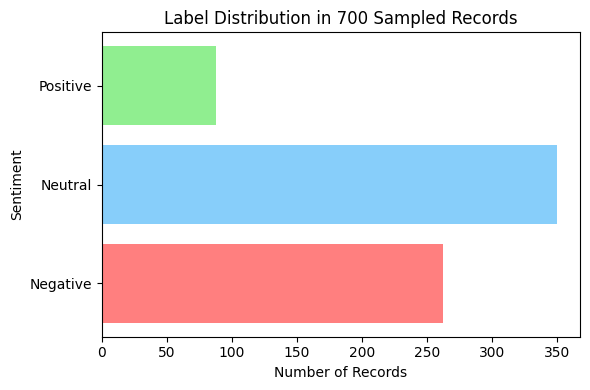

In [ ]:
import matplotlib.pyplot as plt


Reddit_sample = Reddit.sample(n=700, random_state=42).reset_index(drop=True)

# 顯示抽樣後的前幾筆資料
Reddit_sample.head(3)

# 統計各情緒標籤的筆數
label_distribution = Reddit_sample['label'].value_counts().sort_index()

# 將數值標籤轉成文字以利閱讀
label_map = {-1.0: 'Negative', 0.0: 'Neutral', 1.0: 'Positive'}
labels = [label_map.get(x, x) for x in label_distribution.index]

# 畫出水平長條圖
plt.figure(figsize=(6, 4))
plt.barh(labels, label_distribution.values, color=['#FF7F7F', '#87CEFA', '#90EE90'])
plt.title('Label Distribution in 700 Sampled Records')
plt.xlabel('Number of Records')
plt.ylabel('Sentiment')
plt.tight_layout()
plt.show()


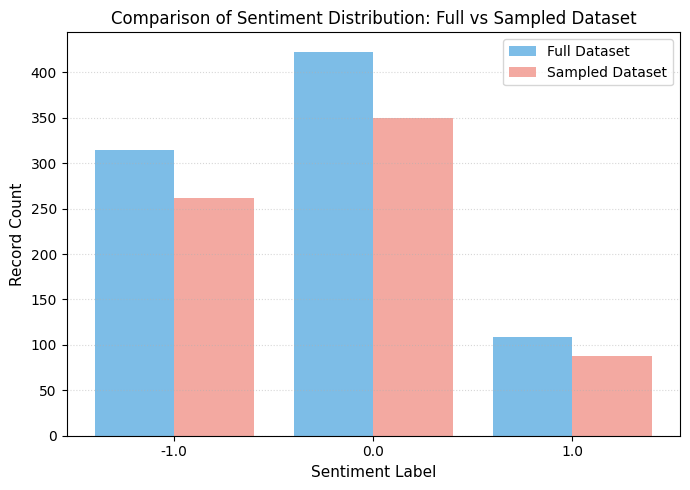

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 計算原始資料與抽樣資料的 label 數量
label_count_full = Reddit['label'].value_counts().sort_index()
label_count_sample = Reddit_sample['label'].value_counts().sort_index()

# 建立 X 軸位置與柱寬
label_index = label_count_full.index.astype(str)
x_pos = np.arange(len(label_index))
bar_w = 0.4

# 建立圖表
plt.figure(figsize=(7, 5))
plt.bar(x_pos, label_count_full, width=bar_w, color='#5DADE2', alpha=0.8, label='Full Dataset')
plt.bar(x_pos + bar_w, label_count_sample, width=bar_w, color='#F1948A', alpha=0.8, label='Sampled Dataset')

# 標題與座標軸設定
plt.title('Comparison of Sentiment Distribution: Full vs Sampled Dataset', fontsize=12)
plt.xlabel('Sentiment Label', fontsize=11)
plt.ylabel('Record Count', fontsize=11)
plt.xticks(x_pos + bar_w/2, label_index)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.5)

# 排版與顯示
plt.tight_layout()
plt.show()


In [9]:

import nltk
from sklearn.feature_extraction.text import CountVectorizer

# 確保分詞器已安裝
nltk.download('punkt', quiet=True)

# 初始化文字向量化器
vectorizer = CountVectorizer(tokenizer=nltk.word_tokenize)

# 將文字欄位轉換為詞頻矩陣
X_bow = vectorizer.fit_transform( Reddit['text'])

# 顯示第二筆文件的向量結果
print("Vector representation of document index 1:")
print(X_bow[1])


Vector representation of document index 1:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 26 stored elements and shape (1, 4534)>
  Coords	Values
  (0, 3839)	1
  (0, 484)	1
  (0, 2146)	2
  (0, 2431)	1
  (0, 4399)	1
  (0, 1274)	1
  (0, 4003)	1
  (0, 1522)	1
  (0, 2525)	1
  (0, 267)	1
  (0, 635)	1
  (0, 1189)	1
  (0, 272)	2
  (0, 3771)	1
  (0, 2283)	1
  (0, 3993)	1
  (0, 1684)	1
  (0, 3008)	1
  (0, 260)	1
  (0, 2773)	1
  (0, 987)	1
  (0, 3620)	1
  (0, 1525)	2
  (0, 3939)	1
  (0, 3048)	1
  (0, 41)	1


c:\Users\jack\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [10]:

# 取得 CountVectorizer 內建的文字分析函式
text_analyzer = vectorizer.build_analyzer()

# 分析第二筆文件的 tokens
sample_text = Reddit.loc[1, 'text']
tokens = text_analyzer(sample_text)

# 印出結果（只顯示前 25 個 token）
print("Tokens extracted from document index 1:")
print(tokens[:25])


print(tokens)



Tokens extracted from document index 1:
['stunt', 'as', 'in', 'like', 'why', 'did', 'they', 'even', 'make', 'a', 'big', 'deal', 'about', 'starting', 'it', 'in', 'the', 'first', 'place', '?', 'no', 'company', 'should', 'ever', 'talk']
['stunt', 'as', 'in', 'like', 'why', 'did', 'they', 'even', 'make', 'a', 'big', 'deal', 'about', 'starting', 'it', 'in', 'the', 'first', 'place', '?', 'no', 'company', 'should', 'ever', 'talk', 'about', 'politics', 'ever', '.']


In [11]:

# EX10 find out where the non-zero elements are
row, col = X_bow[:50,:500].toarray().nonzero()
print(row)
print(col)
vectorizer.get_feature_names_out()[col[10]]


[ 1  1  1  1  1  2  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  4  5  6  6  6  6  6  6  6  6  7  7  7  7  8  8  8  8  8  8  9  9  9
  9  9 10 10 10 11 12 13 13 13 13 13 13 13 13 13 13 13 17 17 17 17 17 17
 17 18 19 19 19 19 19 19 19 19 19 19 19 19 22 22 22 23 23 23 23 23 23 23
 23 24 24 25 25 25 26 26 27 27 28 28 28 28 29 30 30 30 30 30 31 31 31 31
 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31
 31 31 31 31 31 31 31 31 31 31 31 32 32 32 34 34 35 35 35 35 35 35 35 36
 36 36 36 36 38 38 39 39 39 39 39 40 40 40 40 41 42 42 44 44 44 44 44 44
 44 44 44 45 45 45 45 46 46 46 46 46 46 46 47 47 47 47 47 48 48 48 48 48
 48 48 48 49 49 49 49]
[ 41 260 267 272 484  41   0  11  15  18  19  20  23  41  83 255 261 263
 267 272 291 292 293 416 423  41  23  23  41  44 267 322 385 423 470  23
  41 119 267   4  41 215 260 267 401   0   2  41  67 423  15  41 267  23
  23   3  23  41  67  95 151 176 201 260 267 443  23  41 124 267 423 440
 484 423  41 267 310 397 401

')'

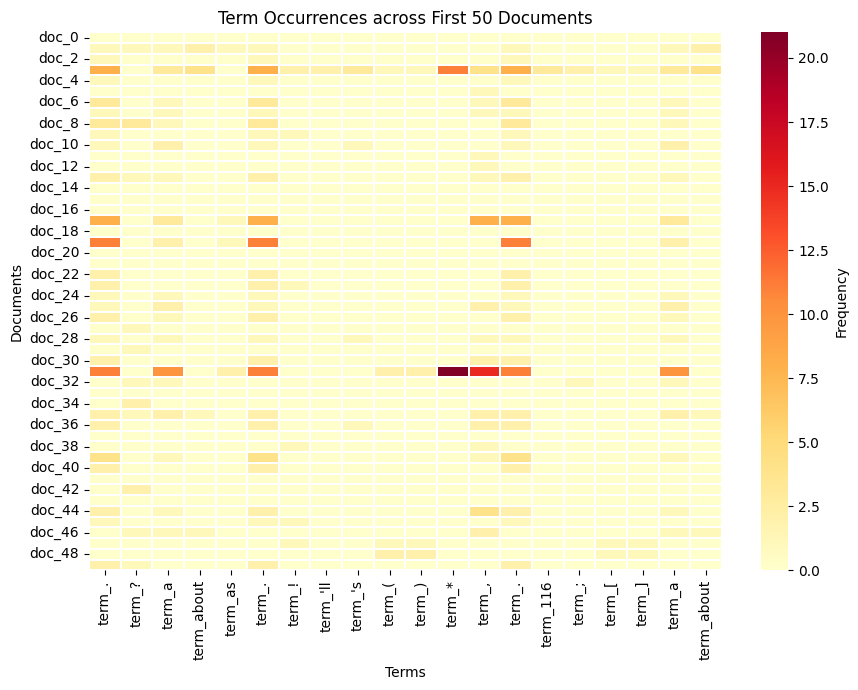

In [12]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 取前 50 篇文件與前 500 個詞
sub_matrix = X_bow[:50, :500].toarray()

# 找出非零元素 (代表該 term 在該文件中出現過)
rows, cols = np.nonzero(sub_matrix)

# 選取前 20 個非零詞的索引（避免圖太擠）
selected_terms_idx = cols[:20]

# 建立 heatmap 對應的軸標籤與數值
x_labels = [f"term_{i}" for i in vectorizer.get_feature_names_out()[selected_terms_idx]]
y_labels = [f"doc_{i}" for i in Reddit.index[:50]]
z_values = X_bow[:50, selected_terms_idx].toarray()

# 建立 DataFrame 並畫 heatmap
heatmap_df = pd.DataFrame(z_values, columns=x_labels, index=y_labels)

plt.figure(figsize=(9, 7))
sns.heatmap(
    heatmap_df,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Frequency'}
)
plt.title("Term Occurrences across First 50 Documents")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.tight_layout()
plt.show()


In [13]:
term_freq = np.ravel(X_bow.sum(axis=0))

# 檢查第一個詞的出現次數
print("Frequency of the first term:", term_freq[0])

Frequency of the first term: 136


In [ ]:

import pandas as pd
import plotly.express as px
import re

# 過濾詞彙：只保留「由英文字母或數字組成」的 term
terms = vectorizer.get_feature_names_out()
mask = [bool(re.match(r'^[A-Za-z0-9]+$', t)) for t in terms]
filtered_terms = terms[mask]
filtered_freq = term_freq[mask]

# 取前 300 個符合條件的 term
df_filtered = pd.DataFrame({
    'term': filtered_terms[:300],
    'frequency': filtered_freq[:300]
})

# 畫出互動式長條圖
fig = px.bar(
    df_filtered,
    x='term',
    y='frequency',
    title='Frequency Distribution of English/Alphanumeric Terms (Top 300)',
    labels={'term': 'Term', 'frequency': 'Frequency'}
)

fig.update_layout(
    xaxis_tickangle=-45,
    width=1000,
    height=500
)
fig.show()


In [15]:


# 設定頻率下限，可依需求調整
min_freq = 7

# 找出所有出現次數 >= min_freq 的詞彙索引
valid_idx = np.where(term_freq >= min_freq)[0]

# 建立 DataFrame 並準備繪圖資料
freq_df = pd.DataFrame({
    'term': vectorizer.get_feature_names_out()[valid_idx],
    'frequency': term_freq[valid_idx]
})

# 使用 Plotly 繪製 bar chart
fig = px.bar(
    freq_df,
    x='term',
    y='frequency',
    title=f"Terms with Frequency ≥ {min_freq}",
    labels={'term': 'Term', 'frequency': 'Frequency'}
)

fig.update_layout(
    xaxis_tickangle=-45,
    width=1000,
    height=500
)
fig.show()


In [16]:
# 設定最低出現次數門檻
min_freq = 10
idx = np.where(term_freq >= min_freq)[0]

# 建立 DataFrame 並依頻率排序
term_freq_df = pd.DataFrame({
    'term': vectorizer.get_feature_names_out()[idx],
    'frequency': term_freq[idx]
}).sort_values(by='frequency', ascending=False).reset_index(drop=True)

# 定義前 10% 為 Head，其餘為 Tail
head_cutoff = int(len(term_freq_df) * 0.1)

# 建立圖表
fig = go.Figure()

# Head 區段（前 10%）
fig.add_trace(go.Scatter(
    x=term_freq_df['term'][:head_cutoff],
    y=term_freq_df['frequency'][:head_cutoff],
    mode='lines+markers',
    fill='tozeroy',
    fillcolor='rgba(144, 238, 144, 0.5)',  # 淡綠
    line=dict(color='green', width=2),
    name='Head (Top 10%)'
))

# Tail 區段（後 90%）
fig.add_trace(go.Scatter(
    x=term_freq_df['term'][head_cutoff:],
    y=term_freq_df['frequency'][head_cutoff:],
    mode='lines',
    fill='tozeroy',
    fillcolor='rgba(255, 215, 0, 0.4)',  # 黃色
    line=dict(color='orange', width=1.5),
    name='Tail (Bottom 90%)'
))

# 美化圖表
fig.update_layout(
    title=f"Long Tail Distribution of Terms (freq ≥ {min_freq})",
    xaxis_title="Terms (sorted by frequency)",
    yaxis_title="Frequency",
    xaxis_tickangle=-45,
    width=1000,
    height=500,
    legend=dict(x=0.02, y=0.98)
)

fig.show()

In [ ]:


# 對所有 term frequency 做 log 轉換（）
term_freq_log = np.log1p(term_freq)  # np.log1p(x) = log(x + 1)

# 設定最低出現次數門檻
min_freq = 10
selected_idx = np.where(term_freq >= min_freq)[0]

# 建立 DataFrame 並依 log 頻率排序
term_freq_df = pd.DataFrame({
    "term": vectorizer.get_feature_names_out()[selected_idx],
    "log_frequency": term_freq_log[selected_idx]
}).sort_values(by="log_frequency", ascending=False).reset_index(drop=True)

# 定義前 10% 為 head，其餘為 tail
split_point = int(len(term_freq_df) * 0.1)

# 繪製長尾曲線（使用 log scale）
fig = go.Figure()

# Head 區段（Top 10%）
fig.add_trace(go.Scatter(
    x=term_freq_df["term"][:split_point],
    y=term_freq_df["log_frequency"][:split_point],
    mode='lines+markers',
    fill='tozeroy',
    fillcolor='rgba(173, 255, 47, 0.4)',  # 淡綠
    line=dict(color='green', width=2),
    name='Head (Top 10%)'
))

# Tail 區段（Bottom 90%）
fig.add_trace(go.Scatter(
    x=term_freq_df["term"][split_point:],
    y=term_freq_df["log_frequency"][split_point:],
    mode='lines',
    fill='tozeroy',
    fillcolor='rgba(255, 255, 102, 0.5)',  # 淡黃
    line=dict(color='orange', width=1.5),
    name='Tail (Bottom 90%)'
))

# 設定圖表樣式
fig.update_layout(
    title="Log-Scaled Term Frequency Distribution (Long Tail Visualization)",
    xaxis_title="Terms (sorted by log frequency)",
    yaxis_title="log(1 + Frequency)",
    xaxis_tickangle=-45,
    width=1000,
    height=500,
    legend=dict(x=0.02, y=0.98)
)

fig.show()


第三部分:在 新資料集 上，嘗試額外的分析任務

In [18]:
import plotly.express as px
import pandas as pd

# Label 分佈（正面、負面、中立）
label_counts = Reddit['label'].value_counts().sort_index()
label_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

df_label = pd.DataFrame({
    'Sentiment': [label_map[k] for k in label_counts.index],
    'Count': label_counts.values
})

fig_label = px.bar(
    df_label,
    x='Sentiment',
    y='Count',
    color='Sentiment',
    text='Count',
    title='Distribution of Sentiment Labels',
    color_discrete_sequence=['lightcoral', 'lightgray', 'lightgreen']
)
fig_label.update_traces(textposition='outside')
fig_label.update_layout(yaxis_title='Number of Records', xaxis_title='Label Type')
fig_label.show()


In [19]:
# 統計每個 type 下各 label 的數量
stack_df = Reddit.groupby(['type', 'label']).size().reset_index(name='count')
stack_df['label'] = stack_df['label'].map(label_map)

fig_stacked = px.bar(
    stack_df,
    x='type',
    y='count',
    color='label',
    text='count',
    title='Type vs Sentiment Distribution',
    color_discrete_sequence=['lightcoral', 'lightgray', 'lightgreen']
)
fig_stacked.update_traces(textposition='inside')
fig_stacked.update_layout(barmode='stack', xaxis_title='Type', yaxis_title='Count')
fig_stacked.show()


In [20]:
# 每日 Label 統計
Reddit['date'] = pd.to_datetime(Reddit['datetime']).dt.date
time_label = Reddit.groupby(['date', 'label']).size().reset_index(name='count')
time_label['label'] = time_label['label'].map(label_map)

fig_time = px.line(
    time_label,
    x='date',
    y='count',
    color='label',
    markers=True,
    title='Sentiment Trend Over Time'
)
fig_time.update_layout(xaxis_title='Date', yaxis_title='Number of Posts')
fig_time.show()


# Phase 2

In [ ]:

import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

# For text features & ML
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

# For pattern mining
from PAMI.extras.convert.DF2DB import DF2DB as _DF2DB
from PAMI.frequentPattern.basic import FPGrowth
from PAMI.frequentPattern.topk.FAE import FAE

# For visualization
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap


import io
class DF2DB(_DF2DB):
    def convert2TransactionalDatabase(self, oFile, condition, thresholdValue):
        transactions = self._DF2DB__findTransactions(condition, thresholdValue)
        with io.open(oFile, 'w', encoding='utf-8') as f:
            for txn in transactions:
                f.write('\t'.join(map(str, txn)) + '\n')



# 1) Load dataset
Reddit = pd.read_csv("newdataset/Reddit-stock-sentiment.csv")

# Keep only the columns we need
Reddit = Reddit[['subreddit', 'text']].dropna().reset_index(drop=True)

# Group by subreddit
subreddits = Reddit['subreddit'].unique()
groups = {name: Reddit[Reddit['subreddit'] == name].copy() for name in subreddits}

# Helper: build Term-Document Matrix for a df
def build_tdm(df):
    vec = CountVectorizer()
    mat = vec.fit_transform(df['text'])
    vocab = vec.get_feature_names_out()
    return pd.DataFrame(mat.toarray(), columns=vocab)

# Build TDM per subreddit
tdm_by_sub = {name: build_tdm(groups[name]) for name in subreddits}

# Helper: remove bottom 1% and top 5% frequent terms within a TDM
def trim_extreme_terms(tdm_df, top=0.05, bottom=0.01):
    freq = tdm_df.sum(axis=0).sort_values()
    n = len(freq)
    n_head = max(1, int(n * top))
    n_tail = max(1, int(n * bottom))
    drops = list(freq.head(n_tail).index) + list(freq.tail(n_head).index)

    print("\n[Filtered words]")
    print("- Bottom {}%: {}".format(bottom*100, list(freq.head(n_tail).index)))
    print("- Top {}%: {}".format(top*100, list(freq.tail(n_head).index)))

    return tdm_df.drop(columns=drops, errors="ignore")

# Apply term trimming
trimmed_tdm = {}
for name in subreddits:
    print(f"\n### Processing subreddit: {name} ###")
    trimmed_tdm[name] = trim_extreme_terms(tdm_by_sub[name], top=0.05, bottom=0.01)

# Show one example TDM
example_idx = 0
example_sub = subreddits[example_idx]
print(f"\n>>> Filtered TDM example → subreddit: {example_sub}, shape={trimmed_tdm[example_sub].shape}")
display(trimmed_tdm[example_sub].head())



### Processing subreddit: wallstreetbets ###

[Filtered words]
- Bottom 1.0%: ['being', '100', '1000', '10k', '12', '17th', '186', 'should', '1934']
- Top 5.0%: ['make', 'she', 'with', 'if', 'go', 'see', 'market', 'about', 'no', 'good', 'puts', 'up', 'what', 'there', 'will', 'now', 'we', 'not', 'target', 'be', 'over', 'all', 'was', 'have', 'are', 'at', 'can', 'but', 'just', 'like', 'so', 't5_2th52', 'emote', 'img', 'on', 'that', 'my', 'of', 'this', 'they', 'for', 'you', 'is', 'in', 'and', 'it', 'the', 'to']

### Processing subreddit: StockMarket ###

[Filtered words]
- Bottom 1.0%: ['behaviour', 'amazon', 'ahead', 'ai', 'quoting', 'wars', 'washing', 'voted', 'vs', 'wait', 'wake', 'radical', 'walked', 'wanna', '45']
- Top 5.0%: ['xi', 'get', 'why', 'other', 'now', 'think', 'by', 'even', 'don', 'should', 'only', 'everyone', 'good', 'an', 'money', 'market', 'say', 'right', 'any', 'president', 'when', 'make', 'people', 'would', 'out', 'up', 'like', 'who', 'doing', 'my', 'doesn', 'going', 

,10,18630,1981,1m,20,200k,2012,2021,208,234,...,wutang,xi,year,years,yesterday,yet,yippee,your,yourself,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:



import csv

for sub_name, tdm_df in trimmed_tdm.items():
    clean_name = sub_name.replace('.', '_')
    tx_file = f"td_freq_db_{clean_name}.csv"

    with open(tx_file, "w", encoding="utf-8", newline="") as f:
        writer = csv.writer(f, delimiter="\t")

        # Each row = transactional representation (list of words appearing in that post)
        for _, row in tdm_df.iterrows():
            items = row[row >= 1].index.tolist()  # word appears → include
            writer.writerow(items)

    print(f"[OK] Transaction DB generated (UTF-8) → {tx_file}")

print("\n[EX17 A1 Completed] All subreddit transaction files saved.\n")



from PAMI.frequentPattern.basic.FPGrowth import FPGrowth

min_sup = 9

pattern_stockmarket = FPGrowth(iFile="td_freq_db_StockMarket.csv", minSup=min_sup, sep="\t")
pattern_stockmarket.mine()
df_stockmarket = pattern_stockmarket.getPatternsAsDataFrame()
pattern_stockmarket.save("patterns_stockmarket_sup9.txt")

pattern_stocks = FPGrowth(iFile="td_freq_db_stocks.csv", minSup=min_sup, sep="\t")
pattern_stocks.mine()
df_stocks = pattern_stocks.getPatternsAsDataFrame()
pattern_stocks.save("patterns_stocks_sup9.txt")

pattern_stbt = FPGrowth(iFile="td_freq_db_stockstobuytoday.csv", minSup=min_sup, sep="\t")
pattern_stbt.mine()
df_stbt = pattern_stbt.getPatternsAsDataFrame()
pattern_stbt.save("patterns_stockstobuytoday_sup9.txt")

pattern_wsb = FPGrowth(iFile="td_freq_db_wallstreetbets.csv", minSup=min_sup, sep="\t")
pattern_wsb.mine()
df_wsb = pattern_wsb.getPatternsAsDataFrame()
pattern_wsb.save("patterns_wallstreetbets_sup9.txt")

print("[EX17 A2] FP-Growth mining completed.\n")



import pandas as pd

# group mined pattern dataframes
dfs_all = [df_stockmarket, df_stocks, df_stbt, df_wsb]

# count occurrences of each pattern
pattern_freq = {}
for df in dfs_all:
    for p in df["Patterns"]:
        pattern_freq[p] = pattern_freq.get(p, 0) + 1

# keep patterns that appear only once across all categories
unique_list = {p for p, c in pattern_freq.items() if c == 1}

# count for reporting
total_count = sum(len(df) for df in dfs_all)
removed_count = total_count - len(unique_list)

# filter each dataframe to keep only unique patterns
filtered_list = [df[df["Patterns"].isin(unique_list)] for df in dfs_all]

# merge and sort
final_patterns = pd.concat(filtered_list, ignore_index=True).sort_values(by="Support", ascending=False)

print("[EX17 A3] Unique pattern table (TOP 10 preview):")
print(final_patterns.head(10))
print(f"\nRemaining unique patterns: {len(final_patterns)}")
print(f"Patterns discarded: {removed_count}")


[OK] Transaction DB generated (UTF-8) → td_freq_db_wallstreetbets.csv
[OK] Transaction DB generated (UTF-8) → td_freq_db_StockMarket.csv
[OK] Transaction DB generated (UTF-8) → td_freq_db_stockstobuytoday.csv
[OK] Transaction DB generated (UTF-8) → td_freq_db_stocks.csv

[EX17 A1 Completed] All subreddit transaction files saved.

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Frequent patterns were generated successfully using frequentPatternGrowth algorithm
[EX17 A2] FP-Growth mining completed.

[EX17 A3] Unique pattern table (TOP 10 preview):
   Patterns Support
21    since      11
20    point      11
3     there      10
19     know      10
18     shit      10
17       go      10
16      him      10
15     does      10
12     make       9
14   reddit       9

Remaining unique patter

In [ ]:

import pandas as pd
from PAMI.frequentPattern.topk.FAE import FAE as FAE_TopK
from PAMI.frequentPattern.maximal.MaxFPGrowth import MaxFPGrowth

file_name = 'td_freq_db_stocks.csv'   # you can change this file
topk_list = [400, 500, 600]
minsup_list = [3, 6, 9]

result = pd.DataFrame(columns=['algorithm', 'parameter', 'patterns', 'runtime'])

# ---- Run FAE (Top-K) ----
for k in topk_list:
    fae = FAE_TopK(iFile=file_name, k=k, sep='\t')
    fae.mine()
    result.loc[len(result)] = ['FAE (Top-K)', k, len(fae.getPatterns()), fae.getRuntime()]
    print(f"[FAE] Top-{k}: {len(fae.getPatterns())} patterns, runtime={fae.getRuntime():.4f}s")

# Run MaxFPGrowth
for sup in minsup_list:
    maxfp = MaxFPGrowth(iFile=file_name, minSup=sup)
    maxfp.mine()
    result.loc[len(result)] = ['MaxFPGrowth', sup, len(maxfp.getPatterns()), maxfp.getRuntime()]
    print(f"[MaxFP] minSup={sup}: {len(maxfp.getPatterns())} patterns, runtime={maxfp.getRuntime():.4f}s")

print("\n=== EX17 Result Summary ===")
print(result)


 TopK frequent patterns were successfully generated using FAE algorithm.
[FAE] Top-400: 400 patterns, runtime=0.0745s
 TopK frequent patterns were successfully generated using FAE algorithm.
[FAE] Top-500: 500 patterns, runtime=0.6017s
 TopK frequent patterns were successfully generated using FAE algorithm.
[FAE] Top-600: 600 patterns, runtime=0.6948s
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
[MaxFP] minSup=3: 363 patterns, runtime=0.0098s
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
[MaxFP] minSup=6: 113 patterns, runtime=0.0041s
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
[MaxFP] minSup=9: 19 patterns, runtime=0.0022s

=== EX17 Result Summary ===
     algorithm  parameter  patterns   runtime
0  FAE (Top-K)        400       400  0.074487
1  FAE (Top-K)        500       500  0.601721
2  FAE (Top-K)        600       600  0.694815
3  MaxFPGrowth          3       363  0

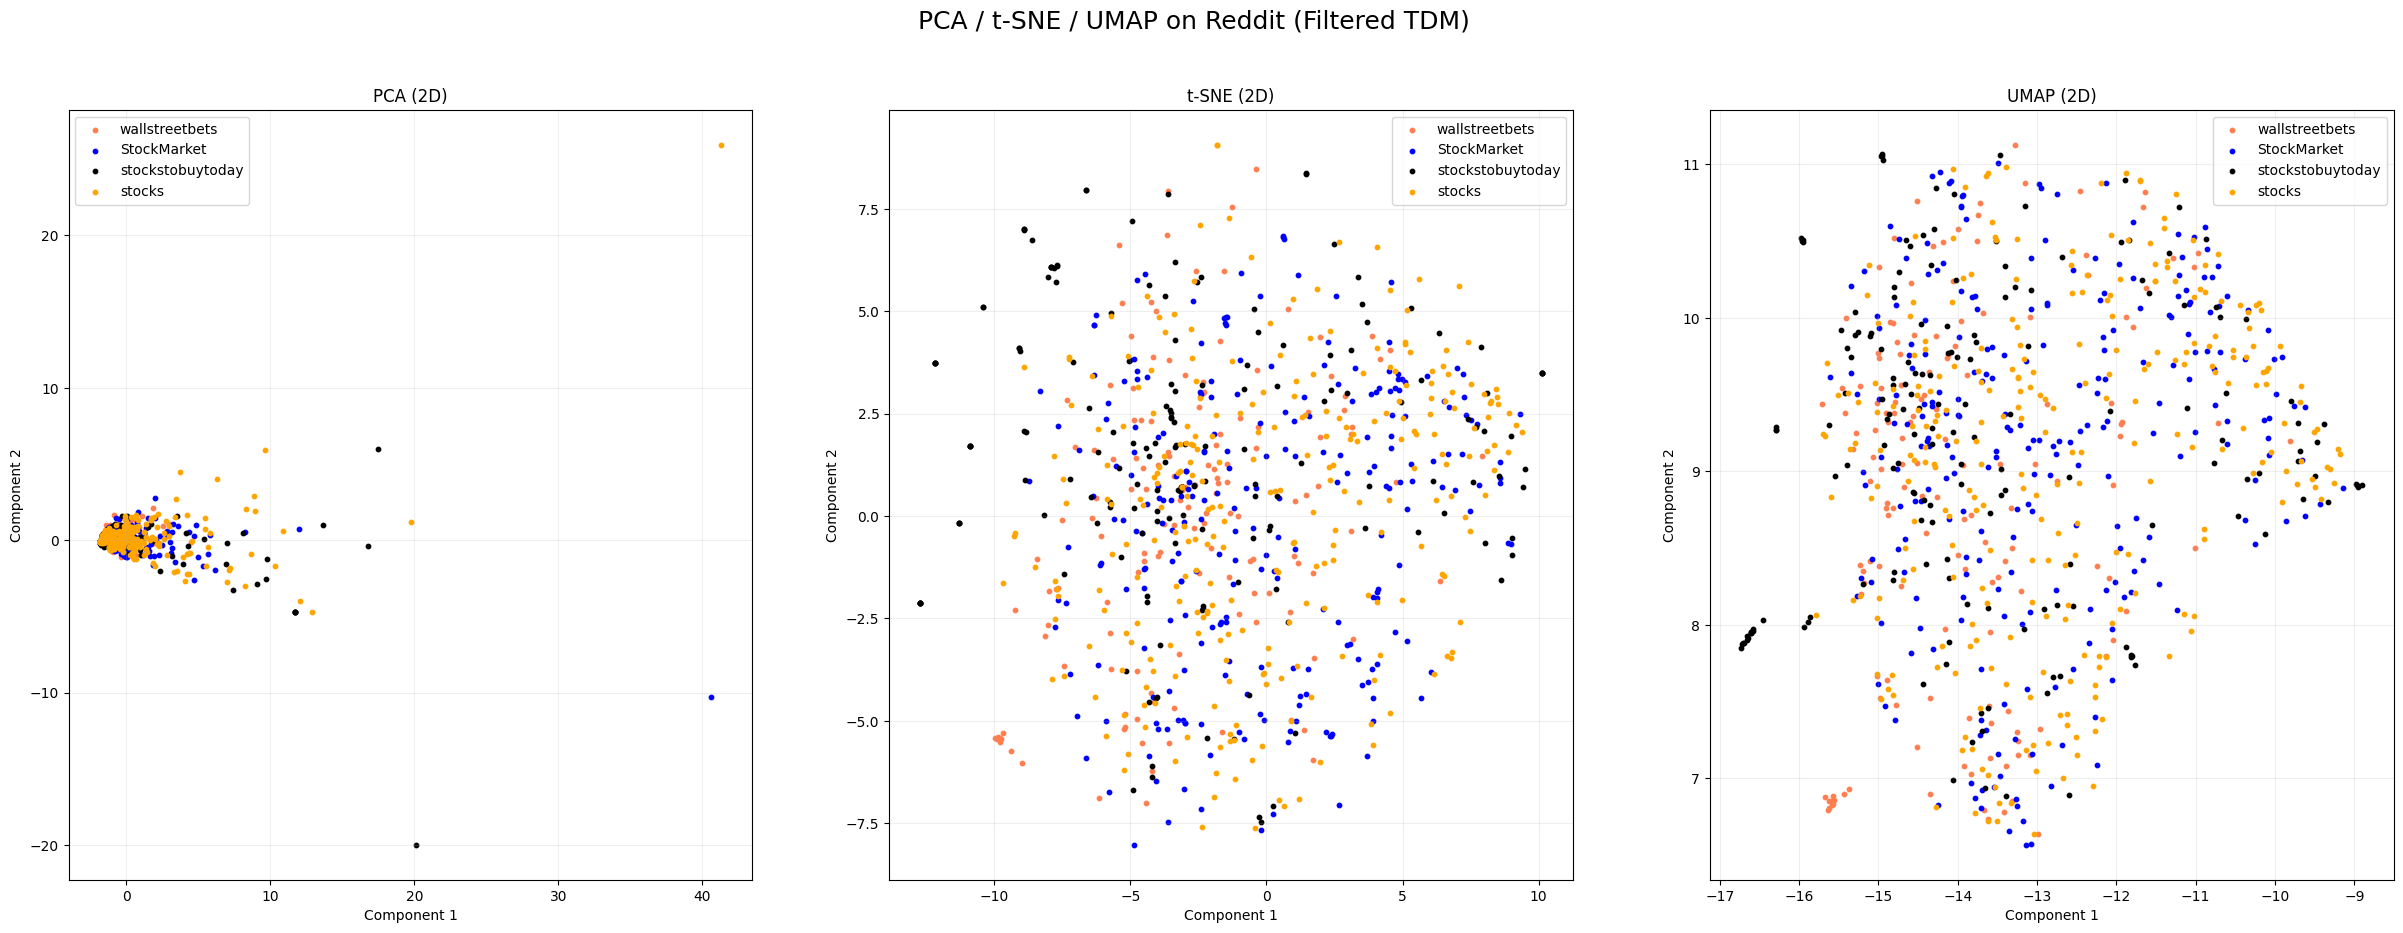

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt

# Use the filtered TDM 
matrix_2d = tdm_df.values
labels = Reddit.loc[tdm_df.index, 'subreddit']  # align labels to TDM rows
unique_labels = labels.unique()

# Dimensionality Reduction 
pca_2d = PCA(n_components=2).fit_transform(matrix_2d)
tsne_2d = TSNE(n_components=2, random_state=42).fit_transform(matrix_2d)
umap_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(matrix_2d)

# Colors 
my_colors = ['coral', 'blue', 'black', 'orange']

fig, ax_list = plt.subplots(1, 3, figsize=(30, 10))
fig.suptitle('PCA / t-SNE / UMAP on Reddit (Filtered TDM)', fontsize=18)

def draw(ax, reduced_matrix, title):
    for color, cat in zip(my_colors, unique_labels):
        mask = (labels == cat)
        ax.scatter(reduced_matrix[mask, 0], reduced_matrix[mask, 1],
                   s=10, c=color, label=cat)
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.grid(alpha=0.2)
    ax.legend()

draw(ax_list[0], pca_2d, 'PCA (2D)')
draw(ax_list[1], tsne_2d, 't-SNE (2D)')
draw(ax_list[2], umap_2d, 'UMAP (2D)')
plt.show()


Frequent patterns were generated successfully using frequentPatternGrowth algorithm
[OK] frequent patterns loaded: 113
[OK] augmented_df shape: (847, 4459)


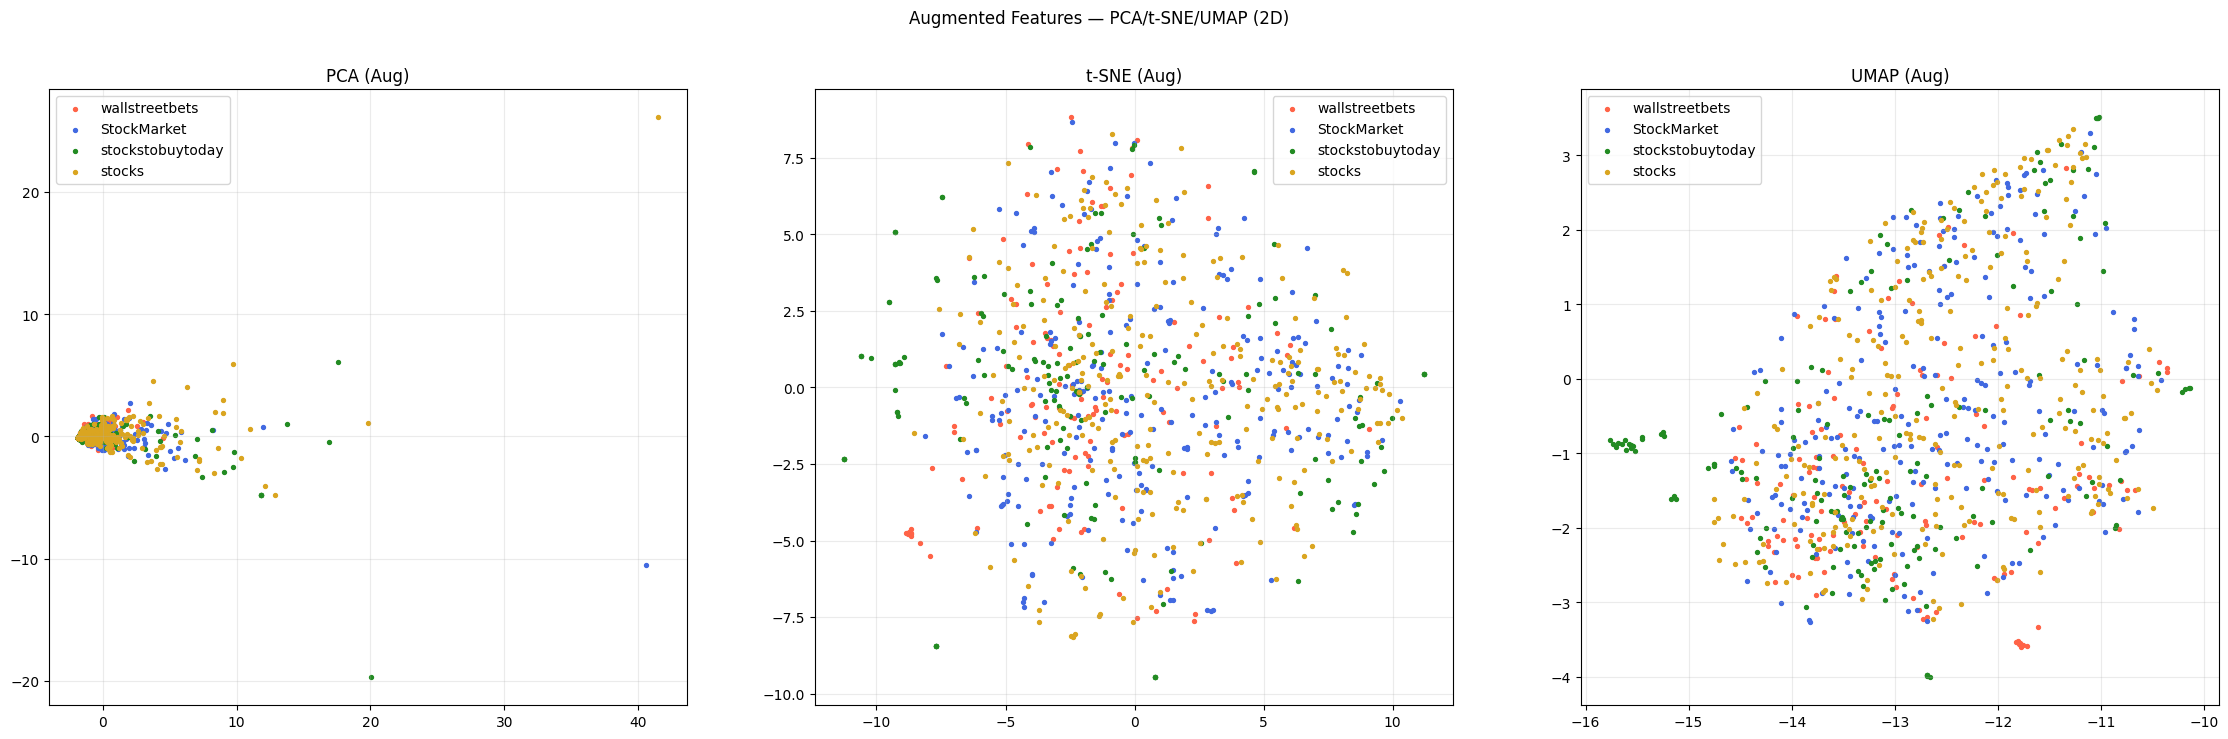

In [ ]:

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from PAMI.frequentPattern.basic.FPGrowth import FPGrowth
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt

# Step 1: Run FPGrowth on one subreddit (stocks) to get patterns 
fp = FPGrowth(iFile="td_freq_db_stocks.csv", minSup=6, sep="\t")
fp.mine()
final_pattern_df = fp.getPatternsAsDataFrame()
final_pattern_df['Patterns'] = final_pattern_df['Patterns'].astype(str)   # ensure string

print("[OK] frequent patterns loaded:", len(final_pattern_df))

# Step 2: Build TDM (Count Vector) from Reddit text 
count_vect = CountVectorizer()
X_tdm = count_vect.fit_transform(Reddit['text'])
terms = count_vect.get_feature_names_out()

# Step 3: Tokenize text for pattern matching 
Reddit['tokenized_text'] = (
    Reddit['text']
    .str.lower()
    .str.replace(r'[^a-z\s]', '', regex=True)
    .str.split()
    .apply(set)
)

# Step 4: Build Pattern-Matrix 
pattern_list = final_pattern_df['Patterns'].tolist()
pattern_matrix = pd.DataFrame(0, index=Reddit.index, columns=pattern_list)

for p in pattern_list:
    token_set = set(p.split())
    pattern_matrix[p] = Reddit['tokenized_text'].apply(lambda doc: 1 if token_set.issubset(doc) else 0)


tdm_df = pd.DataFrame(X_tdm.toarray(), columns=terms, index=Reddit.index)
augmented_df = pd.concat([tdm_df, pattern_matrix], axis=1)

print("[OK] augmented_df shape:", augmented_df.shape)
augmented_df.head()

aug_values = augmented_df.to_numpy()
labels = Reddit['subreddit']
subs = labels.unique()

# reduce
pca2 = PCA(n_components=2).fit_transform(aug_values)
tsne2 = TSNE(n_components=2, random_state=42).fit_transform(aug_values)
umap2 = umap.UMAP(n_components=2, random_state=42).fit_transform(aug_values)

colors = ['tomato', 'royalblue', 'forestgreen', 'goldenrod']

def draw(ax, embed, title):
    for col, sub in zip(colors, subs):
        mask = (labels == sub)
        ax.scatter(embed[mask, 0], embed[mask, 1], s=8, c=col, label=sub)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()

fig, ax = plt.subplots(1, 3, figsize=(28, 8))
fig.suptitle("Augmented Features — PCA/t-SNE/UMAP (2D)")

draw(ax[0], pca2,  "PCA (Aug)")
draw(ax[1], tsne2, "t-SNE (Aug)")
draw(ax[2], umap2, "UMAP (Aug)")

plt.show()



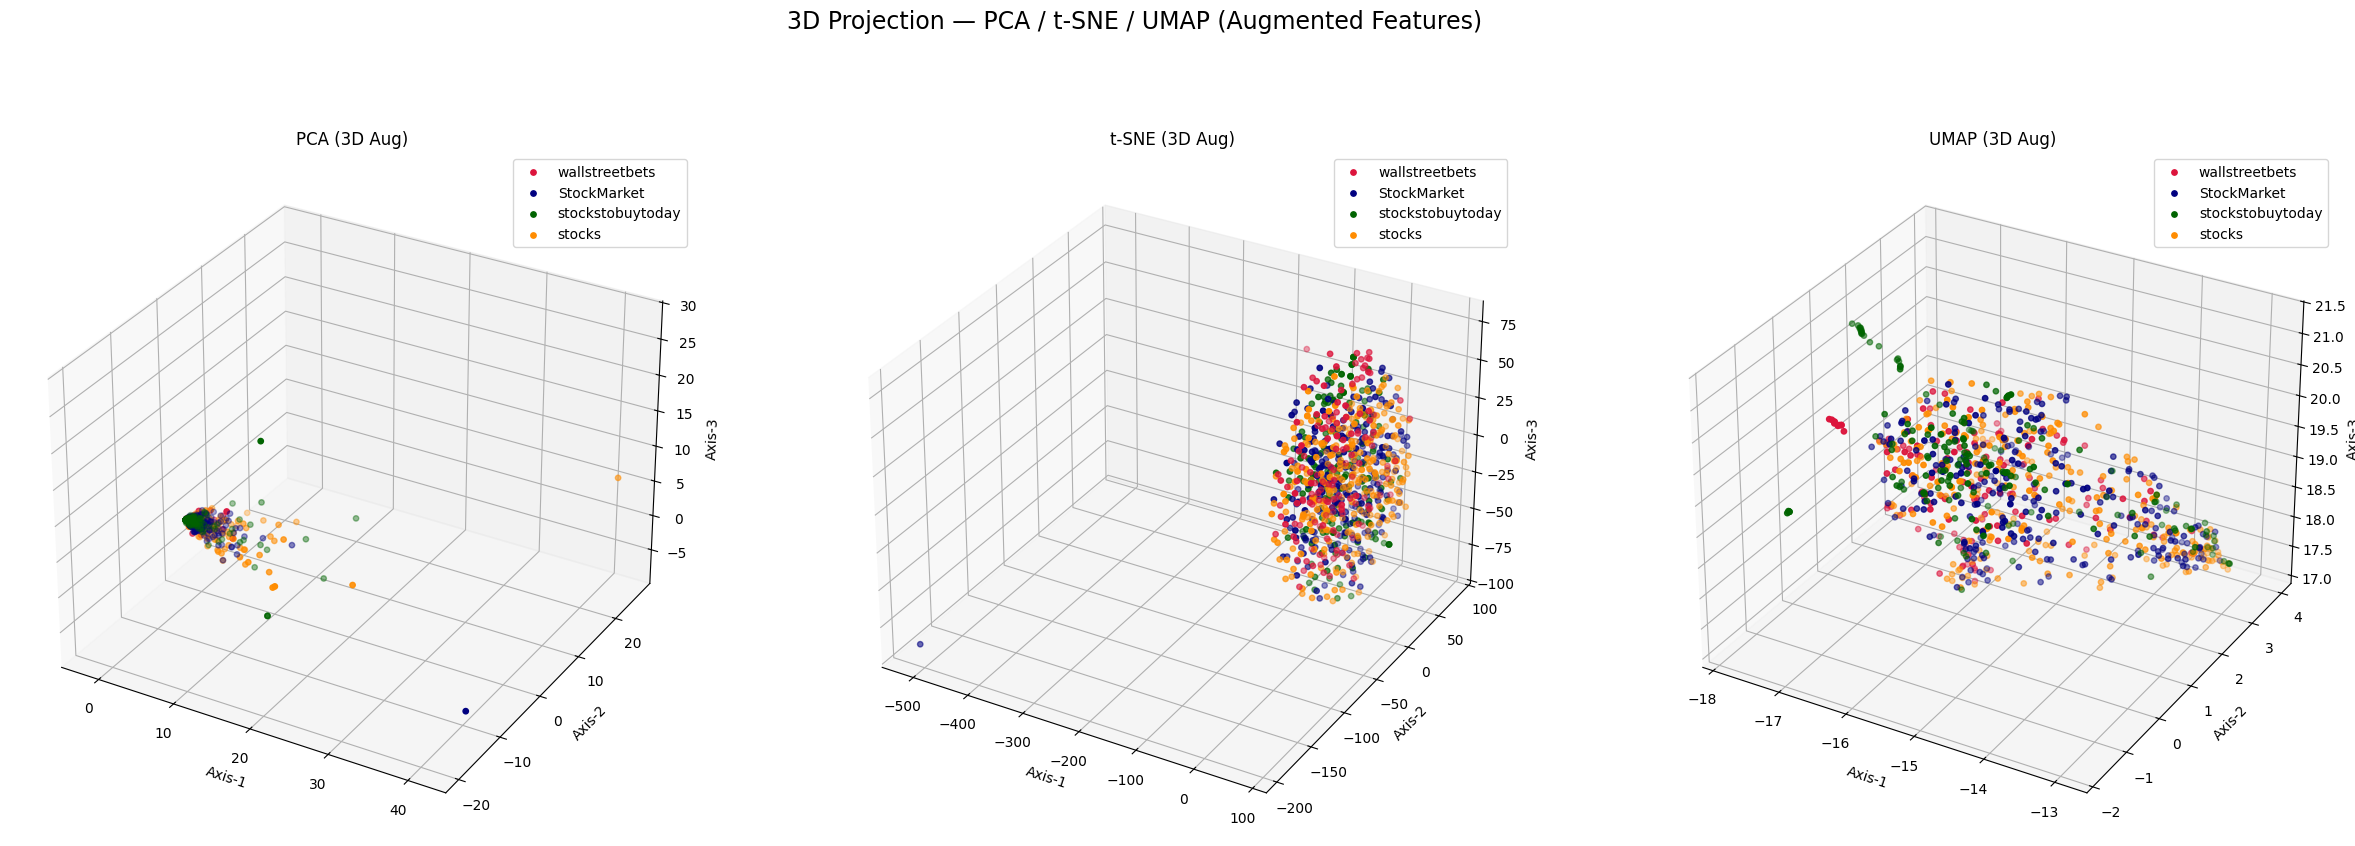

In [ ]:
# EX18 — 3D Visualization on Augmented Features
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D plotting

# Step 1: Dimensionality reduction (3D)
aug_values = augmented_df.to_numpy()

pca_3d = PCA(n_components=3).fit_transform(aug_values)
tsne_3d = TSNE(n_components=3, random_state=42).fit_transform(aug_values)
umap_3d = umap.UMAP(n_components=3, random_state=42).fit_transform(aug_values)

# Step 2: label and color setup
labels3d = Reddit['subreddit']
groups3d = labels3d.unique()
color_set = ['crimson', 'navy', 'darkgreen', 'darkorange']  # different from 2D version

# Step 3: 3D plotting function
def scatter3d(ax, embed, title):
    for col, grp in zip(color_set, groups3d):
        mask = (labels3d == grp)
        ax.scatter(embed[mask, 0], embed[mask, 1], embed[mask, 2],
                   s=15, c=col, label=grp)
    ax.set_title(title)
    ax.set_xlabel("Axis-1")
    ax.set_ylabel("Axis-2")
    ax.set_zlabel("Axis-3")
    ax.grid(alpha=0.25)
    ax.legend()

# Step 4: Create subplots (PCA / t-SNE / UMAP)
fig = plt.figure(figsize=(30, 10))
fig.suptitle("3D Projection — PCA / t-SNE / UMAP (Augmented Features)", fontsize=17)

ax_pca = fig.add_subplot(131, projection='3d')
ax_tsne = fig.add_subplot(132, projection='3d')
ax_umap = fig.add_subplot(133, projection='3d')

scatter3d(ax_pca, pca_3d,  "PCA (3D Aug)")
scatter3d(ax_tsne, tsne_3d, "t-SNE (3D Aug)")
scatter3d(ax_umap, umap_3d, "UMAP (3D Aug)")

plt.show()


In [ ]:
# EX19 — Encode subreddit using LabelBinarizer
from sklearn import preprocessing

# 建立 LabelBinarizer 並套用於 subreddit 欄位
lb_sub = preprocessing.LabelBinarizer()
lb_sub.fit(Reddit['subreddit'])

# 轉成 one-hot 並存回 dataframe
Reddit['subreddit_onehot'] = lb_sub.transform(Reddit['subreddit']).tolist()

# 顯示前 9 筆結果
print(Reddit[['subreddit', 'subreddit_onehot']].head(9))


          subreddit subreddit_onehot
0    wallstreetbets     [0, 0, 0, 1]
1    wallstreetbets     [0, 0, 0, 1]
2       StockMarket     [1, 0, 0, 0]
3  stockstobuytoday     [0, 0, 1, 0]
4       StockMarket     [1, 0, 0, 0]
5    wallstreetbets     [0, 0, 0, 1]
6            stocks     [0, 1, 0, 0]
7    wallstreetbets     [0, 0, 0, 1]
8            stocks     [0, 1, 0, 0]


In [ ]:
#  EX20 — Cosine Similarity on Selected Reddit Posts
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import binarize

# pick 3 sample documents (you may change the indices)
doc_a = Reddit.iloc[25]['text']
doc_b = Reddit.iloc[250]['text']
doc_c = Reddit.iloc[500]['text']

# convert to list for vectorizer
samples = [[doc_a], [doc_b], [doc_c]]

# vectorize original text
vec_a = count_vect.transform(samples[0])
vec_b = count_vect.transform(samples[1])
vec_c = count_vect.transform(samples[2])

# binarize (presence / absence of words)
bin_a = binarize(vec_a)
bin_b = binarize(vec_b)
bin_c = binarize(vec_c)

# pairwise cosine similarity
sim_ab = cosine_similarity(bin_a, bin_b)[0][0]
sim_ac = cosine_similarity(bin_a, bin_c)[0][0]
sim_bc = cosine_similarity(bin_b, bin_c)[0][0]

# self-similarity (diagonal = always 1.0)
sim_aa = cosine_similarity(bin_a, bin_a)[0][0]
sim_bb = cosine_similarity(bin_b, bin_b)[0][0]
sim_cc = cosine_similarity(bin_c, bin_c)[0][0]

# print results
print(f"Cosine Similarity (doc A vs B): {sim_ab:.4f}")
print(f"Cosine Similarity (doc A vs C): {sim_ac:.4f}")
print(f"Cosine Similarity (doc B vs C): {sim_bc:.4f}")

print(f"Cosine Similarity (doc A vs A): {sim_aa:.4f}")
print(f"Cosine Similarity (doc B vs B): {sim_bb:.4f}")
print(f"Cosine Similarity (doc C vs C): {sim_cc:.4f}")


Cosine Similarity (doc A vs B): 0.0253
Cosine Similarity (doc A vs C): 0.0000
Cosine Similarity (doc B vs C): 0.1056
Cosine Similarity (doc A vs A): 1.0000
Cosine Similarity (doc B vs B): 1.0000
Cosine Similarity (doc C vs C): 1.0000


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Ensure Reddit has category column
Reddit['category'] = Reddit['subreddit'].astype('category').cat.codes

# Step 1: build mapping from category id subreddit name
label_dict = (
    Reddit[['category', 'subreddit']]
    .drop_duplicates()
    .set_index('category')['subreddit']
    .to_dict()
)

# sorted target name list for report output
class_names = [label_dict[c] for c in sorted(label_dict.keys())]

# Step 2: train-test split (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(
    tdm_df, Reddit['category'], test_size=0.3, random_state=42
)

# Step 3: Train Naive Bayes classifier
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Step 4: predict + evaluate
y_pred = nb_model.predict(X_test)

print(" Naive Bayes Result on TDM")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=class_names, digits=4))


=== Naive Bayes Result on TDM ===
Accuracy: 0.5529411764705883

Classification Report:
                   precision    recall  f1-score   support

     StockMarket     0.5570    0.6111    0.5828        72
          stocks     0.4885    0.7356    0.5872        87
stockstobuytoday     0.7826    0.3673    0.5000        49
  wallstreetbets     0.6818    0.3191    0.4348        47

        accuracy                         0.5529       255
       macro avg     0.6275    0.5083    0.5262       255
    weighted avg     0.6000    0.5529    0.5411       255



In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Prepare feature matrix and label column
X_augmented = np.concatenate((tdm_df.to_numpy(), augmented_df.to_numpy()), axis=1)
y = Reddit['category']  # use numeric labels

# Split the augmented data
X_train, X_test, y_train, y_test = train_test_split(
    X_augmented, y, test_size=0.3, random_state=42
)

# Train Naive Bayes on augmented features
nb_aug = MultinomialNB()
nb_aug.fit(X_train, y_train)

# Predict
y_pred = nb_aug.predict(X_test)

# Evaluation report
print("Naive Bayes on Augmented Features")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

# Map category numbers back to subreddit names for readability
label_dict = (
    Reddit[['category', 'subreddit']]
    .drop_duplicates()
    .set_index('category')['subreddit']
    .to_dict()
)

target_names = [label_dict[i] for i in sorted(label_dict.keys())]
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=target_names, digits=4))


=== Naive Bayes on Augmented Features ===
Accuracy: 0.5529

Classification Report:
                   precision    recall  f1-score   support

     StockMarket     0.5600    0.5833    0.5714        72
          stocks     0.5041    0.7126    0.5905        87
stockstobuytoday     0.7600    0.3878    0.5135        49
  wallstreetbets     0.5625    0.3830    0.4557        47

        accuracy                         0.5529       255
       macro avg     0.5966    0.5167    0.5328       255
    weighted avg     0.5798    0.5529    0.5455       255



In [ ]:
# EX23: Decicion Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# Prepare labels
y = Reddit['category']

# Train/test split (same data rule as EX22, but using only TDM)
X_train, X_test, y_train, y_test = train_test_split(
    tdm_df, y, test_size=0.3, random_state=42
)

# Train Decision Tree
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

# Predict
y_pred_dt = dt_clf.predict(X_test)

# Map numeric labels beck to subreddit names
label_dict = (
    Reddit[['category', 'subreddit']]
    .drop_duplicates()
    .set_index('category')['subreddit']
    .to_dict()
)
target_names = [label_dict[i] for i in sorted(label_dict.keys())]

# Evaluation
print("Decision Tree on TDM")
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 4))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_dt, target_names=target_names, digits=4))


=== Decision Tree on TDM ===
Accuracy: 0.4392

Classification Report:
                   precision    recall  f1-score   support

     StockMarket     0.4156    0.4444    0.4295        72
          stocks     0.4930    0.4023    0.4430        87
stockstobuytoday     0.5581    0.4898    0.5217        49
  wallstreetbets     0.3281    0.4468    0.3784        47

        accuracy                         0.4392       255
       macro avg     0.4487    0.4458    0.4432       255
    weighted avg     0.4533    0.4392    0.4424       255



In [ ]:
# EX24: Decision Tree (Augmented Features) 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Train/Test split using augmented_df
y_aug = Reddit['category']
X_aug_train, X_aug_test, y_aug_train, y_aug_test = train_test_split(
    augmented_df, y_aug, test_size=0.3, random_state=42
)

# Train decision tree on augmented features
dt_aug = DecisionTreeClassifier(random_state=42)
dt_aug.fit(X_aug_train, y_aug_train)

# Predict
y_aug_pred = dt_aug.predict(X_aug_test)

# Create label subreddit mapping (same as EX23)
label_dict = (
    Reddit[['category', 'subreddit']]
    .drop_duplicates()
    .set_index('category')['subreddit']
    .to_dict()
)
target_names = [label_dict[i] for i in sorted(label_dict.keys())]

# Evaluation
print("Decision Tree on Augmented Data ")
print("Accuracy:", round(accuracy_score(y_aug_test, y_aug_pred), 4))
print("\nClassification Report:\n",
      classification_report(y_aug_test, y_aug_pred, target_names=target_names, digits=4))


=== Decision Tree on Augmented Data ===
Accuracy: 0.4157

Classification Report:
                   precision    recall  f1-score   support

     StockMarket     0.3735    0.4306    0.4000        72
          stocks     0.4730    0.4023    0.4348        87
stockstobuytoday     0.5641    0.4490    0.5000        49
  wallstreetbets     0.3051    0.3830    0.3396        47

        accuracy                         0.4157       255
       macro avg     0.4289    0.4162    0.4186       255
    weighted avg     0.4315    0.4157    0.4200       255

